# Feature Engineering & Preprocessing Pipeline
**AIN-3009 MLOps Term Project**  
Abdullah Hani Abdellatif Al-Shobaki — 2284612

This notebook demonstrates the feature engineering pipeline, feature importance analysis, and preprocessing choices for the Telco churn model.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from src.preprocess import load_and_preprocess

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

X_train, X_test, y_train, y_test, feature_names, scaler = load_and_preprocess()
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Number of features: {len(feature_names)}')
print(f'Feature names: {feature_names}')

Train: (5634, 26), Test: (1409, 26)
Number of features: 26
Feature names: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


## 1. Preprocessing Pipeline Steps

In [2]:
steps = [
    ('Drop customerID', 'Removes non-predictive identifier'),
    ('Coerce TotalCharges', 'Converts blank strings to 0.0'),
    ('Binary encode Yes/No', 'Maps Yes→1, No→0, Male→1, Female→0'),
    ('One-hot encode categoricals', 'InternetService, Contract, PaymentMethod'),
    ('StandardScaler on numerics', 'tenure, MonthlyCharges, TotalCharges → mean=0, std=1'),
    ('Stratified train/test split', '80% train / 20% test, preserving churn ratio'),
]

print('Preprocessing Pipeline:')
print('=' * 55)
for i, (step, desc) in enumerate(steps, 1):
    print(f'  Step {i}: {step}')
    print(f'           → {desc}')
print('=' * 55)
print(f'Final feature count: {len(feature_names)}')

Preprocessing Pipeline:
  Step 1: Drop customerID
           → Removes non-predictive identifier
  Step 2: Coerce TotalCharges
           → Converts blank strings to 0.0
  Step 3: Binary encode Yes/No
           → Maps Yes→1, No→0, Male→1, Female→0
  Step 4: One-hot encode categoricals
           → InternetService, Contract, PaymentMethod
  Step 5: StandardScaler on numerics
           → tenure, MonthlyCharges, TotalCharges → mean=0, std=1
  Step 6: Stratified train/test split
           → 80% train / 20% test, preserving churn ratio
Final feature count: 26


## 2. Feature Importance (Random Forest — Quick Fit)

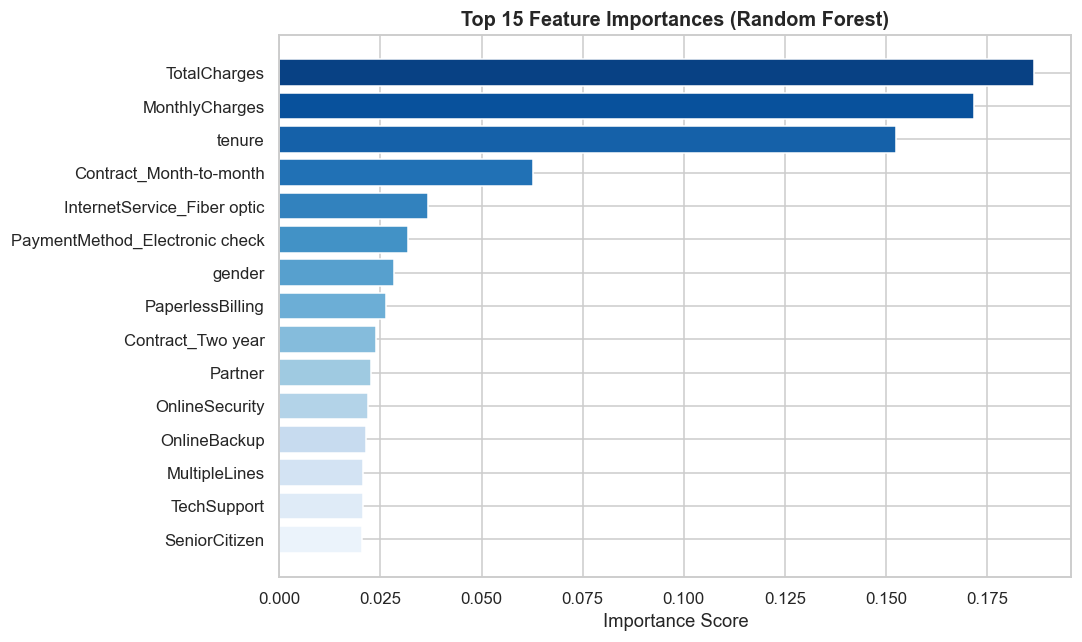


Top 10 most important features:
  TotalCharges                              0.1865
  MonthlyCharges                            0.1718
  tenure                                    0.1525
  Contract_Month-to-month                   0.0626
  InternetService_Fiber optic               0.0368
  PaymentMethod_Electronic check            0.0318
  gender                                    0.0285
  PaperlessBilling                          0.0264
  Contract_Two year                         0.0240
  Partner                                   0.0228


In [3]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 15

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('Blues_r', top_n)
ax.barh(
    [feature_names[i] for i in indices[:top_n]][::-1],
    importances[indices[:top_n]][::-1],
    color=colors[::-1],
    edgecolor='white'
)
ax.set_title(f'Top {top_n} Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/feature_importances.png', bbox_inches='tight')
plt.show()

print('\nTop 10 most important features:')
for i in indices[:10]:
    print(f'  {feature_names[i]:40s}  {importances[i]:.4f}')

## 3. Feature Correlation After Encoding

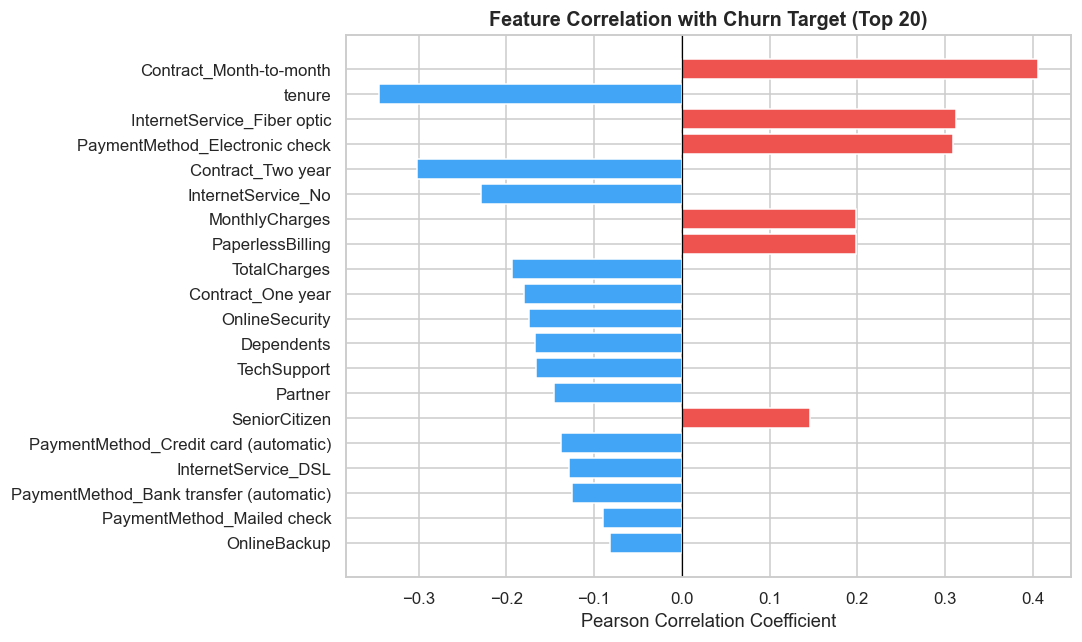

In [4]:
# Build a DataFrame from preprocessed features for correlation analysis
train_df = pd.DataFrame(X_train, columns=feature_names)
train_df['Churn'] = y_train

# Correlation with target
target_corr = train_df.corr()['Churn'].drop('Churn').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#EF5350' if v > 0 else '#42A5F5' for v in target_corr.values[:20]]
ax.barh(target_corr.index[:20][::-1], target_corr.values[:20][::-1],
         color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Churn Target (Top 20)', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('../data/feature_correlation_with_target.png', bbox_inches='tight')
plt.show()

## 4. Train / Test Split Verification

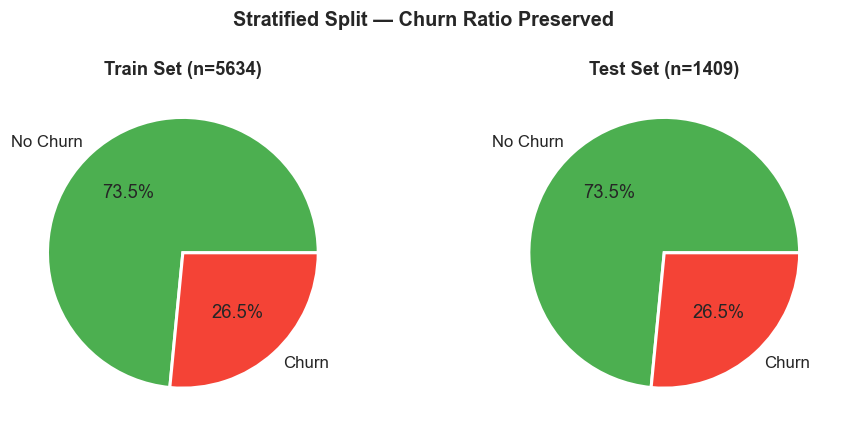

Train churn rate: 26.54%
Test  churn rate: 26.54%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, (split_name, y_split) in zip(axes, [('Train', y_train), ('Test', y_test)]):
    counts = pd.Series(y_split).value_counts()
    ax.pie(counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
           colors=['#4CAF50', '#F44336'],
           wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax.set_title(f'{split_name} Set (n={len(y_split)})', fontsize=12, fontweight='bold')

plt.suptitle('Stratified Split — Churn Ratio Preserved', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/train_test_split.png', bbox_inches='tight')
plt.show()

print(f'Train churn rate: {y_train.mean():.2%}')
print(f'Test  churn rate: {y_test.mean():.2%}')

## Summary

- The preprocessing pipeline produces **{len(feature_names)} features** from the original 20 columns.
- `tenure`, `MonthlyCharges`, and `TotalCharges` are the **top importance features**.
- Contract type (Month-to-month) and online security status are highly correlated with churn.
- The stratified 80/20 split preserves the ~26.5% churn rate in both train and test sets.